In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('used_cars_data.csv')

In [3]:
df.shape

(7253, 14)

In [4]:
df.head

<bound method NDFrame.head of       S.No.                                               Name    Location  \
0         0                             Maruti Wagon R LXI CNG      Mumbai   
1         1                   Hyundai Creta 1.6 CRDi SX Option        Pune   
2         2                                       Honda Jazz V     Chennai   
3         3                                  Maruti Ertiga VDI     Chennai   
4         4                    Audi A4 New 2.0 TDI Multitronic  Coimbatore   
...     ...                                                ...         ...   
7248   7248                  Volkswagen Vento Diesel Trendline   Hyderabad   
7249   7249                             Volkswagen Polo GT TSI      Mumbai   
7250   7250                             Nissan Micra Diesel XV     Kolkata   
7251   7251                             Volkswagen Polo GT TSI        Pune   
7252   7252  Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...       Kochi   

      Year  Kilometers_Driven Fue

In [5]:
df.info

<bound method DataFrame.info of       S.No.                                               Name    Location  \
0         0                             Maruti Wagon R LXI CNG      Mumbai   
1         1                   Hyundai Creta 1.6 CRDi SX Option        Pune   
2         2                                       Honda Jazz V     Chennai   
3         3                                  Maruti Ertiga VDI     Chennai   
4         4                    Audi A4 New 2.0 TDI Multitronic  Coimbatore   
...     ...                                                ...         ...   
7248   7248                  Volkswagen Vento Diesel Trendline   Hyderabad   
7249   7249                             Volkswagen Polo GT TSI      Mumbai   
7250   7250                             Nissan Micra Diesel XV     Kolkata   
7251   7251                             Volkswagen Polo GT TSI        Pune   
7252   7252  Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...       Kochi   

      Year  Kilometers_Driven F

In [6]:
pd.isnull(df).sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [7]:
df.dtypes

S.No.                  int64
Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage                  str
Engine                   str
Power                    str
Seats                float64
New_Price                str
Price                float64
dtype: object

In [8]:
missing_percentage =(df.isnull().sum()/len(df))*100
print(missing_percentage)

S.No.                 0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.027575
Engine                0.634220
Power                 0.634220
Seats                 0.730732
New_Price            86.129877
Price                17.013650
dtype: float64


In [9]:
missing_data = pd.DataFrame({'Missing Values':df.isnull().sum(),'Percentage':missing_percentage})
missing_data

,Missing Values,Percentage
S.No.,0,0.000000
Name,0,0.000000
Location,0,0.000000
Year,0,0.000000
Kilometers_Driven,0,0.000000
Fuel_Type,0,0.000000
Transmission,0,0.000000
Owner_Type,0,0.000000
Mileage,2,0.027575
Engine,46,0.634220


In [10]:
df=df.drop(columns=['New_Price'])

In [11]:
df.shape

(7253, 13)

In [12]:
df.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='str')

In [17]:
df.isnull().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
Price                1234
dtype: int64

In [18]:
df.describe()



,S.No.,Year,Kilometers_Driven,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7200.000000,6019.000000
mean,3626.000000,2013.365366,5.869906e+04,5.279722,9.479468
std,2093.905084,3.254421,8.442772e+04,0.811660,11.187917
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,9.950000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000


In [21]:
df['Mileage']

0       26.60
1       19.67
2       18.20
3       20.77
4       15.20
        ...  
7248    20.54
7249    17.21
7250    23.08
7251    17.20
7252    10.00
Name: Mileage, Length: 7253, dtype: float64

In [22]:
df['Engine_Unit'] = df['Engine'].str.split(' ').str[1]
df['Engine'] = df['Engine'].str.split(' ').str[0].astype(float)

In [25]:
df['Power']=df['Power'].replace('null bhp','0 bhp') 
df['Power_Unit'] = df['Power'].str.split(' ').str[1]
df['Power'] = df['Power'].str.split(' ').str[0].astype(float)

In [31]:
df['Price']=df['Price'].replace('null bhp','0 bhp') 
df['Seats']=df['Seats'].replace('null bhp','0 bhp') 

In [26]:
df[['Mileage','Engine','Power']].isnull().sum()

Mileage     2
Engine     46
Power      46
dtype: int64

In [46]:
df[['Mileage','Engine','Power','Price','Seats']].dtypes

Mileage    float64
Engine     float64
Power      float64
Price      float64
Seats      float64
dtype: object

In [40]:
df['Mileage']=df['Mileage'].fillna(value=df['Mileage'].median())
df['Engine']=df['Engine'].fillna(value=df['Engine'].median())
df['Power']=df['Power'].fillna(value=df['Power'].median())
df['Seats']=df['Seats'].fillna(value=df['Seats'].median())
df['Price']=df['Price'].fillna(value=df['Price'].median())

In [47]:
df.isnull().sum()

S.No.                 0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               0
Engine                0
Power                 0
Seats                 0
Price                 0
Mileage_Unit          2
Engine_Unit          46
Power_Unit           46
dtype: int64

df=df.drop(columns=['Mileage_Unit','Engine_Unit','Power_Unit'])

S.No.                0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [52]:
df.shape

(7253, 13)

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.dtypes

S.No.                  int64
Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
dtype: object

In [55]:
df.describe()

,S.No.,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000
mean,3626.000000,2013.365366,5.869906e+04,18.141586,1615.789742,110.626128,5.277678,8.826235
std,2093.905084,3.254421,8.442772e+04,4.561567,593.475257,54.926631,0.809039,10.293313
min,0.000000,1996.000000,1.710000e+02,0.000000,72.000000,0.000000,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,15.170000,1198.000000,74.000000,5.000000,3.850000
50%,3626.000000,2014.000000,5.341600e+04,18.160000,1493.000000,91.720000,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,21.100000,1968.000000,138.030000,5.000000,8.400000
max,7252.000000,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,160.000000


In [56]:
df['Kilometers_Driven'].sort_values(ascending=False).head(10)

2328    6500000
340      775000
1860     720000
358      620000
2823     480000
3092     480000
4491     445000
6921     350000
3649     300000
1528     299322
Name: Kilometers_Driven, dtype: int64

In [57]:
df['Price'].sort_values(ascending=False).head(10)

4079    160.00
5781    120.00
5919    100.00
1505     97.07
1974     93.67
1984     93.00
4691     90.00
5535     85.00
2095     83.96
2422     79.00
Name: Price, dtype: float64

In [58]:
df['Year'].value_counts().sort_index()

Year
1996      1
1998      4
1999      2
2000      5
2001      8
2002     18
2003     20
2004     35
2005     68
2006     89
2007    148
2008    207
2009    252
2010    407
2011    579
2012    690
2013    791
2014    925
2015    929
2016    886
2017    709
2018    361
2019    119
Name: count, dtype: int64

In [61]:
df=df[df['Kilometers_Driven']<2000000]
df.describe()

,S.No.,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7252.000000,7252.000000,7252.000000,7252.000000,7252.000000,7252.000000,7252.000000,7252.000000
mean,3626.178985,2013.364865,57810.852868,18.141885,1615.599835,110.605806,5.277716,8.818489
std,2093.993978,3.254365,37499.537277,4.561811,593.295744,54.903143,0.809088,10.272861
min,0.000000,1996.000000,171.000000,0.000000,72.000000,0.000000,0.000000,0.440000
25%,1812.750000,2011.000000,34000.000000,15.170000,1198.000000,74.000000,5.000000,3.850000
50%,3626.500000,2014.000000,53404.000000,18.160000,1493.000000,91.720000,5.000000,5.640000
75%,5439.250000,2016.000000,73000.000000,21.100000,1968.000000,138.030000,5.000000,8.400000
max,7252.000000,2019.000000,775000.000000,33.540000,5998.000000,616.000000,10.000000,160.000000


In [63]:
Q1 = df[['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']].quantile(0.25)
Q3 = df[['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']] < (Q1 - 1.5 * IQR)) |
            (df[['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']] > (Q3 + 1.5 * IQR)))
outliers.sum()

Kilometers_Driven     257
Mileage                99
Engine                 65
Power                 272
Seats                1153
Price                 981
dtype: int64

In [64]:
df['Seats'].value_counts().sort_index()

Seats
0.0        1
2.0       18
4.0      119
5.0     6099
6.0       38
7.0      796
8.0      170
9.0        3
10.0       8
Name: count, dtype: int64

In [65]:
df['Power'].value_counts().sort_index()


Power
0.0      129
34.2       9
35.0      19
35.5       1
37.0      15
        ... 
503.0      1
550.0      1
552.0      1
560.0      1
616.0      1
Name: count, Length: 384, dtype: int64

In [70]:
df=df.drop(columns=['S.No.'])

In [71]:
df=df[df['Seats']>0]
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000
mean,2013.365053,57801.586678,18.142939,1615.381740,110.621060,5.278444,8.817222
std,3.254550,37493.819458,4.561242,593.045869,54.891559,0.806766,10.273003
min,1996.000000,171.000000,0.000000,72.000000,0.000000,2.000000,0.440000
25%,2011.000000,34000.000000,15.185000,1198.000000,74.000000,5.000000,3.850000
50%,2014.000000,53392.000000,18.160000,1493.000000,91.720000,5.000000,5.640000
75%,2016.000000,73000.000000,21.100000,1968.000000,138.030000,5.000000,8.400000
max,2019.000000,775000.000000,33.540000,5998.000000,616.000000,10.000000,160.000000


In [72]:
df['Mileage'].value_counts().sort_index()

Mileage
0.00     81
6.40      1
7.50      1
7.81      1
7.94      3
         ..
30.46     2
31.79     2
32.26     5
33.44     4
33.54     5
Name: count, Length: 438, dtype: int64

In [73]:

df['Mileage'] = df['Mileage'].replace(0, np.nan)
df['Power'] = df['Power'].replace(0, np.nan)
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].median())
df['Power'] = df['Power'].fillna(df['Power'].median())
df[['Mileage', 'Power']].describe()

,Mileage,Power
count,7251.000000,7251.000000
mean,18.346249,112.275121
std,4.133527,52.908934
min,6.400000,34.200000
25%,15.400000,77.000000
50%,18.200000,93.700000
75%,21.100000,138.030000
max,33.540000,616.000000


In [74]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000,7251.000000
mean,2013.365053,57801.586678,18.346249,1615.381740,112.275121,5.278444,8.817222
std,3.254550,37493.819458,4.133527,593.045869,52.908934,0.806766,10.273003
min,1996.000000,171.000000,6.400000,72.000000,34.200000,2.000000,0.440000
25%,2011.000000,34000.000000,15.400000,1198.000000,77.000000,5.000000,3.850000
50%,2014.000000,53392.000000,18.200000,1493.000000,93.700000,5.000000,5.640000
75%,2016.000000,73000.000000,21.100000,1968.000000,138.030000,5.000000,8.400000
max,2019.000000,775000.000000,33.540000,5998.000000,616.000000,10.000000,160.000000


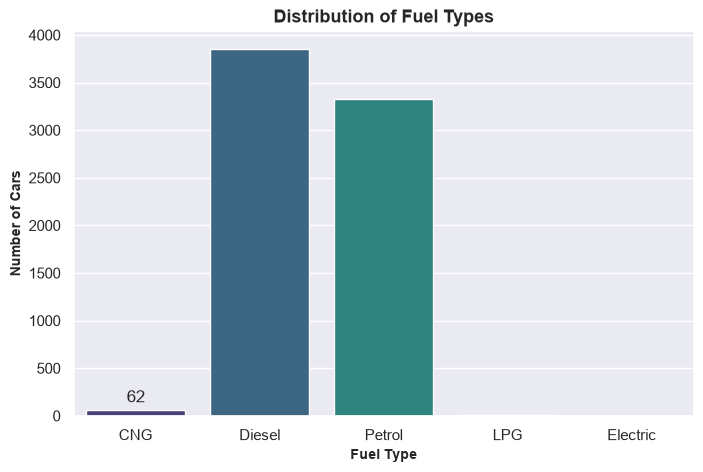

In [89]:

sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Fuel_Type',hue='Fuel_Type', data=df,palette='viridis')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.title("Distribution of Fuel Types", fontsize=13, fontweight='bold')
plt.xlabel("Fuel Type", fontsize=10,fontweight='bold')
plt.ylabel("Number of Cars", fontsize=10,fontweight='bold')
plt.show()

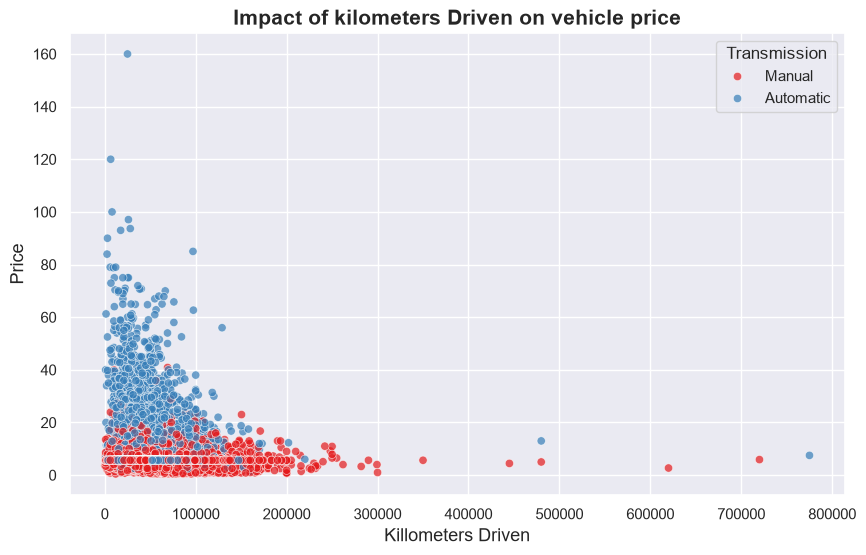

In [93]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Kilometers_Driven',
    y='Price',
    hue='Transmission',
    data=df,
    palette='Set1',
    alpha=0.7)
plt.title("Impact of kilometers Driven on vehicle price", fontsize=15, fontweight='bold')
plt.xlabel("Killometers Driven", fontsize=13)
plt.ylabel("Price", fontsize=13)
plt.legend(title="Transmission")
plt.show()

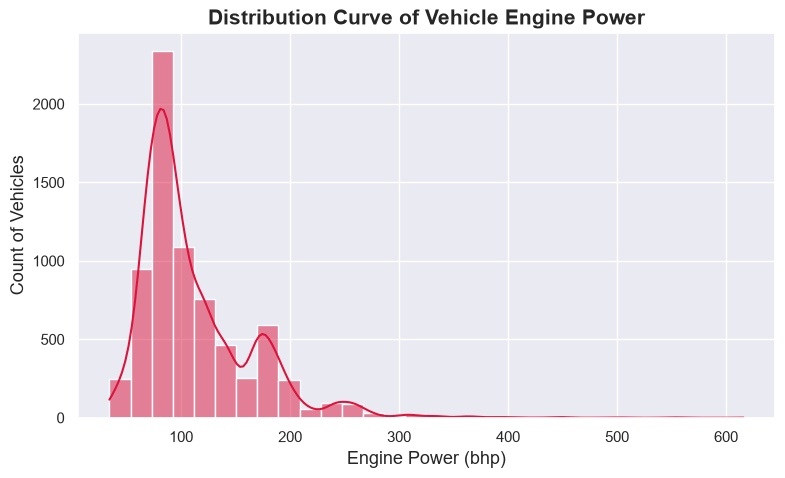

In [96]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Power'], kde=True, color='crimson', bins=30)
plt.title("Distribution Curve of Vehicle Engine Power", fontsize=15, fontweight='bold')
plt.xlabel("Engine Power (bhp)", fontsize=13)
plt.ylabel("Count of Vehicles", fontsize=13)
plt.show()

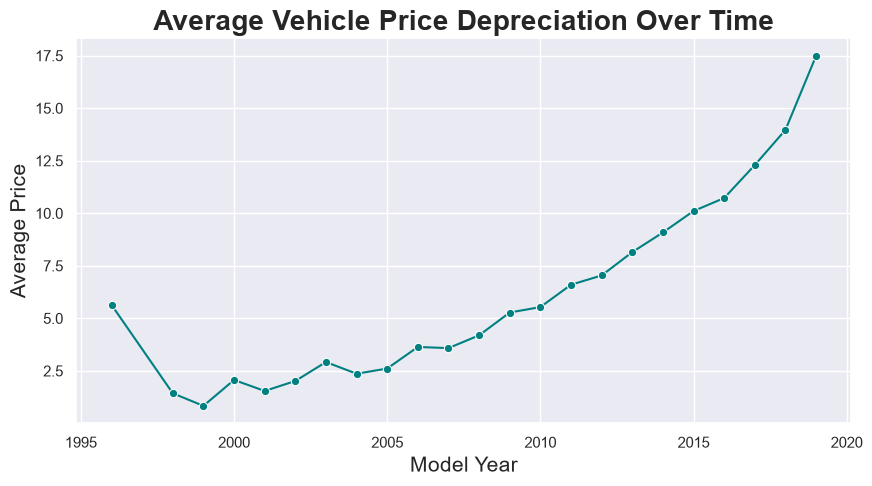

In [98]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='Year', y='Price', data=df, marker='o', color='teal', errorbar=None)
plt.title("Average Vehicle Price Depreciation Over Time", fontsize=20, fontweight='bold')
plt.xlabel("Model Year", fontsize=15)
plt.ylabel("Average Price", fontsize=15)
plt.show()

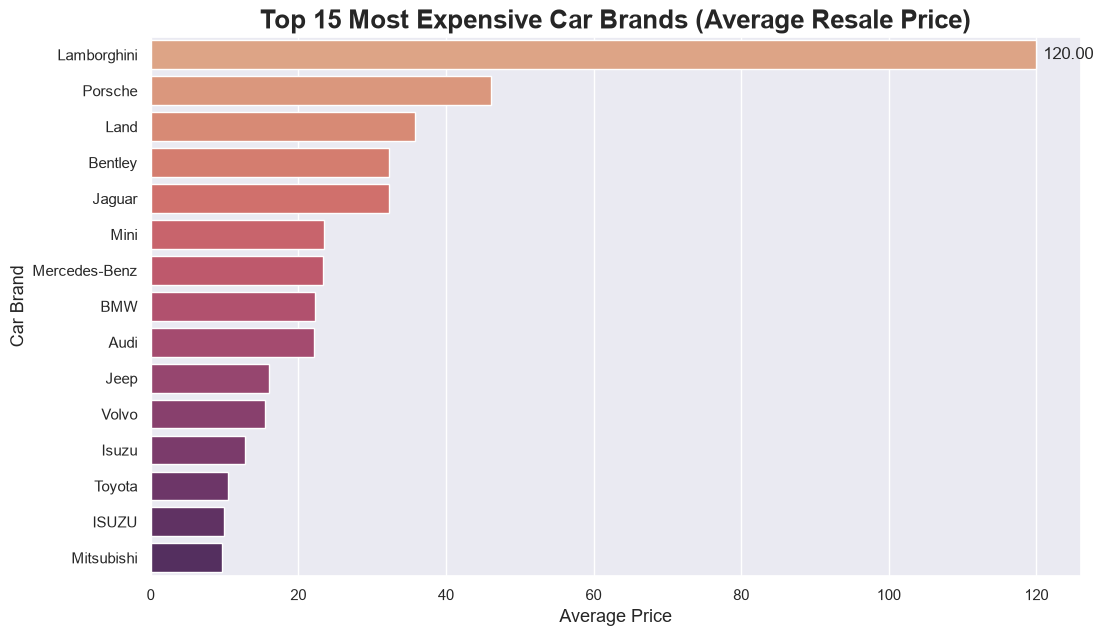

In [101]:

df['Brand'] = df['Name'].str.split().str[0]
brand_prices = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(15).reset_index()
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Price', 
    y='Brand', 
    hue='Brand',
    data=brand_prices, 
    palette='flare', 
    legend=False
)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5)
plt.title("Top 15 Most Expensive Car Brands (Average Resale Price)", fontsize=19, fontweight='bold')
plt.xlabel("Average Price", fontsize=13)
plt.ylabel("Car Brand", fontsize=13)
plt.show() 

In [102]:
df['Car_Age']=2026-df['Year']
df[['Name','Year','Car_Age']]

,Name,Year,Car_Age
0,Maruti Wagon R LXI CNG,2010,16
1,Hyundai Creta 1.6 CRDi SX Option,2015,11
2,Honda Jazz V,2011,15
3,Maruti Ertiga VDI,2012,14
4,Audi A4 New 2.0 TDI Multitronic,2013,13
...,...,...,...
7248,Volkswagen Vento Diesel Trendline,2011,15
7249,Volkswagen Polo GT TSI,2015,11
7250,Nissan Micra Diesel XV,2012,14
7251,Volkswagen Polo GT TSI,2013,13


Text(0, 0.5, 'Average price')

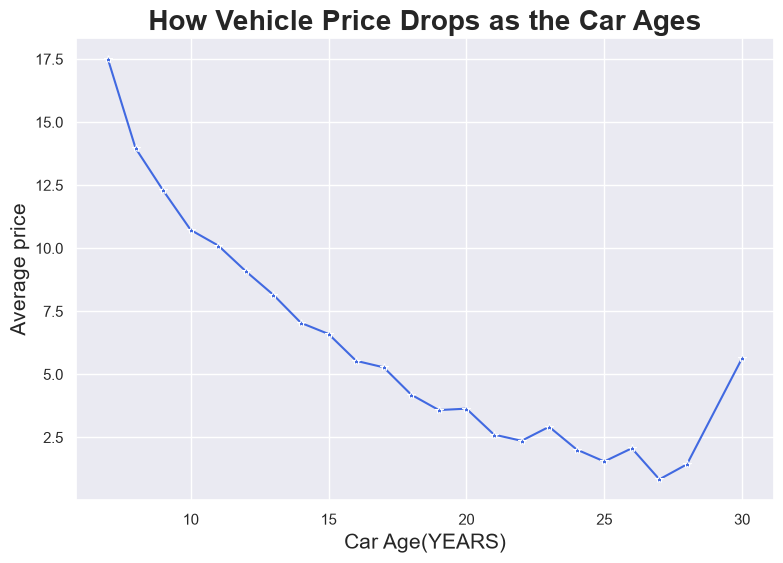

In [103]:
plt.figure(figsize=(9,6))
sns.lineplot(x='Car_Age',y='Price',data=df,marker='*',color='royalblue',errorbar=None)
plt.title("How Vehicle Price Drops as the Car Ages",fontsize=20,fontweight='bold')
plt.xlabel("Car Age(YEARS)",fontsize=15)
plt.ylabel("Average price",fontsize=15)

In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 7251 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7251 non-null   str    
 1   Location           7251 non-null   str    
 2   Year               7251 non-null   int64  
 3   Kilometers_Driven  7251 non-null   int64  
 4   Fuel_Type          7251 non-null   str    
 5   Transmission       7251 non-null   str    
 6   Owner_Type         7251 non-null   str    
 7   Mileage            7251 non-null   float64
 8   Engine             7251 non-null   float64
 9   Power              7251 non-null   float64
 10  Seats              7251 non-null   float64
 11  Price              7251 non-null   float64
 12  Brand              7251 non-null   object 
 13  Car_Age            7251 non-null   int64  
dtypes: float64(5), int64(3), object(1), str(5)
memory usage: 1.2+ MB


In [105]:
df.to_csv('cleaned_car_data.csv', index=False)